# YDANA Interactive Analysis Tutorial
Welcome to the programmatic API of YDANA! While the command-line interface (CLI) is great for submitting batch jobs, sometimes you want to interact with your data dynamically.

In this notebook, we will:
1. Load a lazy `dask_awkward` dataset from ROOT files.
2. **Simple Example:** Inspect the data structure and apply a simple cut.
3. **Complex Example:** Apply preprocessors, fill multiple histograms lazily, and plot the results!

In [4]:
import awkward as ak
import dask_awkward as dak
import dask
import hist
import matplotlib.pyplot as plt

# Import YDANA core tools
from ydana import Config, NTuple
from ydana.base.histos import Histogram

## 1. Load the Dataset
We load our dataset using the `NTuple` class. By passing `root=True`, YDANA uses `NanoEventsFactory` to read the schema and create a lazy computation graph. 
*Note: No data is actually loaded into memory yet!*

In [5]:
# Load the configuration (this parses schema.yaml under the hood)
config = Config("yamls/run_config.yaml")

# Create the NTuple reader
dataset = NTuple(CONFIG=config, verbose=False, in_format="root")

# Extract the 'DY' dataset from the events dictionary
events = dataset.events["DY"]

# Let's look at the structure! Dask-awkward knows the schema without loading the data.
print("Fields in the event:", events.fields)
print("Fields in the genmuons collection:", events.genmuons.fields)

Fields in the event: ['digis', 'segments', 'tps', 'genmuons', 'fwshowers', 'simhits', 'number', 'dR']
Fields in the genmuons collection: ['pt', 'eta', 'phi', 'charge', 'pdgId']


## 2. Simple Example: Array Operations & Cuts
Let's figure out how many events actually contain gen-muons. Because `events` is a lazy `dask_awkward` array, we build the operation first, and then call `.compute()` to execute it.

In [6]:
# 1. Define the mask (True for events with at least one genmuon)
has_muons_mask = dak.num(events.genmuons) > 0

# 2. Apply the mask to the events array
filtered_events = events[has_muons_mask]

# 3. Build the counting tasks
total_events_task = dak.num(events, axis=0)
filtered_events_task = dak.num(filtered_events, axis=0)

# 4. COMPUTE! This is where the actual reading of the ROOT file happens.
total, passed = dask.compute(total_events_task, filtered_events_task)

print(f"Total events:  {total}")
print(f"Passed events: {passed}")

Total events:  1663
Passed events: 1663


## 3. Complex Example: Preprocessors & Histograms
Now let's do real physics! 
1. We will apply a **Preprocessor** to calculate $\Delta R$ between the leading and subleading muons.
2. We will define two **Histograms** using YDANA's wrapper.
3. We will fill them lazily and compute everything in one highly-optimized pass.

In [7]:
import numpy as np

# --- A. Apply a Preprocessor to the filtered events ---
# In programmatic mode, you can write custom variables on the fly!
def add_genmuon_dR(evts):
    has_two = dak.num(evts.genmuons) >= 2
    
    # Pad to ensure there are always at least 2 entries so [:, 0] and [:, 1] don't crash
    eta = dak.pad_none(evts.genmuons.eta, 2, axis=1)
    phi = dak.pad_none(evts.genmuons.phi, 2, axis=1)
    
    # Calculate dR
    d_eta = eta[:, 1] - eta[:, 0]
    d_phi = phi[:, 1] - phi[:, 0]
    
    # Handle phi wrap-around
    d_phi = dak.where(d_phi > np.pi, d_phi - 2.0 * np.pi, d_phi)
    d_phi = dak.where(d_phi < -np.pi, d_phi + 2.0 * np.pi, d_phi)
    
    dR = np.sqrt(d_eta**2 + d_phi**2)
    
    # Assign it as a new field in our lazy array!
    evts["dR"] = dak.where(has_two, dR, -999.0)
    return evts

# Apply the preprocessor
analysis_events = add_genmuon_dR(filtered_events)

# Ensure we only look at events that actually had 2 muons for the histograms
analysis_events = analysis_events[analysis_events.dR != -999.0]

In [10]:
# --- B. Define Histograms ---
# We use the YDANA Histogram wrapper to map the arrays to the axes
h_pt = Histogram(
    hist.axis.Regular(20, 0, 100, name="pt", label=r"Leading muon $p_T$ [GeV]"),
    name="LeadingMuon_pt",
    func=lambda ev: {"pt": ev["genmuons"]["pt"][:, 0]},
)

h_dR = Histogram(
    hist.axis.Regular(20, 0, 6, name="dR", label=r"$\Delta R$ "),
    name="muon_DR",
    func=lambda ev: {"dR": ev["dR"]},
)

# --- C. Lazily Fill ---
# This just adds the filling operations to the Dask graph.
h_pt.fill(analysis_events)
h_dR.fill(analysis_events)

# --- D. Compute! ---
# Trigger the graph execution. Dask will brilliantly optimize this so it 
# only reads the 'genmuons.pt', 'genmuons.eta', and 'genmuons.phi' branches from the ROOT file!
print("Computing histograms...")
filled_pt, filled_dR = dask.compute(h_pt.h, h_dR.h)
print("Done!")

Computing histograms...
Done!


## 4. Plotting the Results
Because YDANA uses the standard `hist` library under the hood, you have full access to its beautiful `matplotlib` integrations!

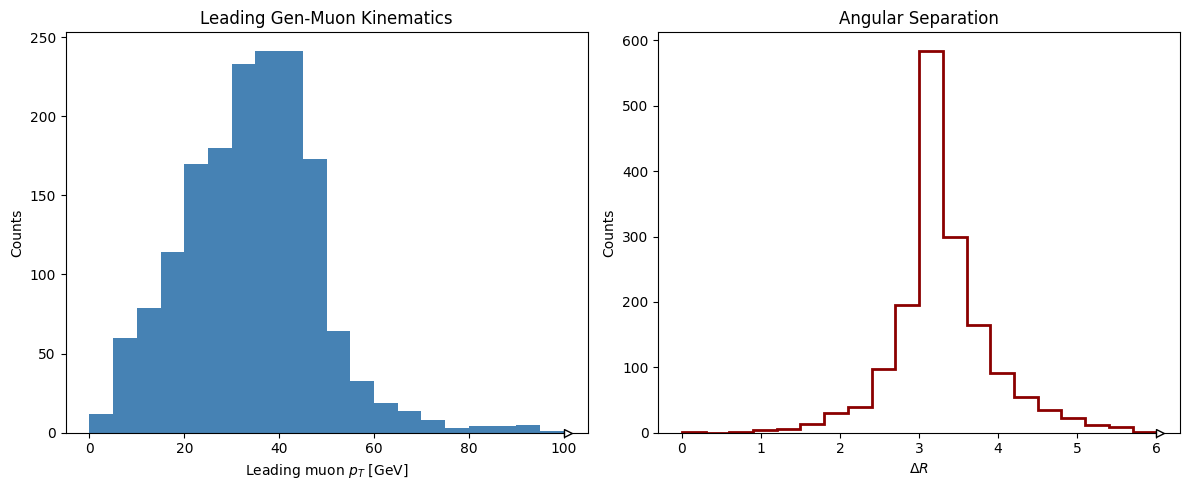

In [11]:
# Create a matplotlib figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Leading pT
filled_pt.plot1d(ax=ax1, histtype='fill', color='steelblue', edgecolor='black')
ax1.set_title("Leading Gen-Muon Kinematics")
ax1.set_ylabel("Counts")

# Plot dR
filled_dR.plot1d(ax=ax2, histtype='step', color='darkred', linewidth=2)
ax2.set_title("Angular Separation")
ax2.set_ylabel("Counts")

plt.tight_layout()
plt.show()

## 5. Publication-Ready Plots with `mplhep`
In High Energy Physics, we have strict styling guidelines for our plots. Thankfully, the `hist` objects returned by YDANA are 100% compatible with `mplhep`, the community standard for plotting!

Let's apply the CMS style and re-plot our histograms.

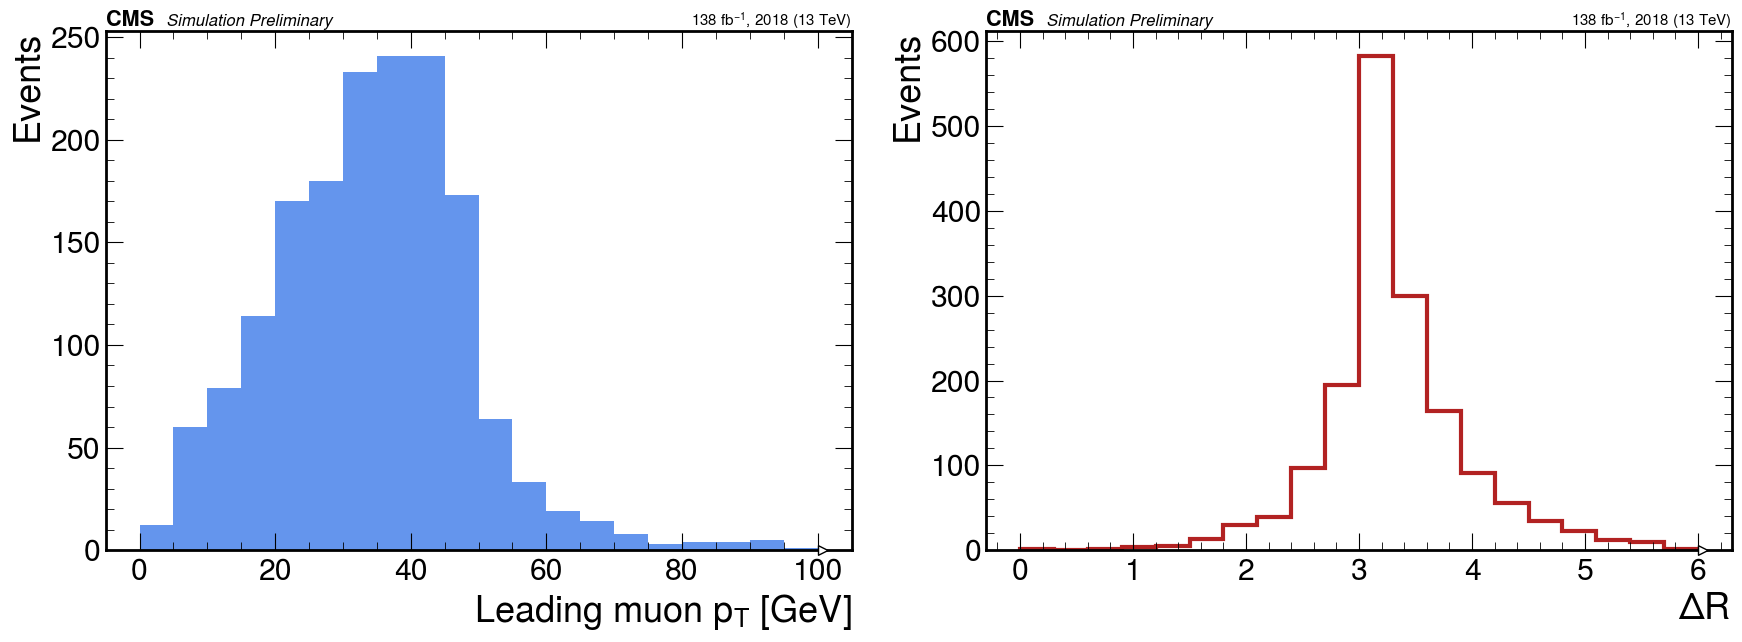

In [14]:
import mplhep as hep

# Apply the official CMS style (changes fonts, tick marks, and layout)
hep.style.use(hep.style.CMS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Leading pT ---
# hep.histplot natively understands our filled YDANA histograms!
hep.histplot(filled_pt, ax=ax1, histtype='fill', color='cornflowerblue', edgecolor='black')

# Add the standard CMS branding
hep.cms.label("Preliminary", data=False, lumi=138, year=2018, ax=ax1, fontsize=12)
ax1.set_ylabel("Events")

# --- Plot 2: Delta R ---
hep.histplot(filled_dR, ax=ax2, histtype='step', color='firebrick', linewidth=3)

hep.cms.label("Preliminary", data=False, lumi=138, year=2018, ax=ax2, fontsize=12)
ax2.set_ylabel("Events")

plt.tight_layout()
plt.show()